# 0  

#### Che cosa è SLM_ANN  
Una rete neurale artificiale che opera "come se" fosse un piccolo modello linguistico, quindi Small Language Model, **SLM**  
#### Come si usa

Con clic su ![](https://terna.to.it/SLM_ANN/binder.png) in alto verso destra; attendendo qualche minuto, il programma diviene funzionante su un computer remoto. Con clic su ![](https://terna.to.it/SLM_ANN/esecuzione.png) il progamma va in esecuzione.  

#### Che prove si possono fare  

Nella casella **3**, se si sostituisce *False* con *True* e si fa clic su ![](https://terna.to.it/SLM_ANN/esecuzioneSpecifica.png) si ottiene il voluminoso output dei parametri del modello.  

Nella casella **5** si possono sostituire i termini in input, prima di tutto seguendo le frasi riportate qui sotto e poi provando a disporre in modo capriccioso le parole e gli spazi. Per eseguire la sola cella 5, in cui si sta lavorando, fare clic su ![](https://terna.to.it/SLM_ANN/esecuzioneSpecifica.png)

Se si usa un termine non compreso nelle frasi riportate, la parola errata è riportata e l'esecuzione si arresta.

===================================================================================================================

Provare a cambiare il valore H nella casella 1 e rieseguire con un numero di nodi nascosti diverso.

  
-----------------------------    
casistica, con **>** che separa l'input dall'output.


il,gatto,mangia,>,il,topo  
il,gatto, ,>,miagola,  
il,cane,mangia,>,il,gatto  
il,cane, ,>,abbaia,  
il,topo,mangia,>,il,formaggio  
il,bimbo,chiama,>,la,mamma  
il,bimbo,mangia,>,la,pappa  
il,bimbo, ,>,piange,  
bimbo,e,gatto,>,giocano,  

# 1
#### dizionari di servizio e numero di nodi nascosti H e funzione per disegnare gli istogrammi

In [1]:
H = 10

inputPhrase =[0]*3

dictionary = \
 {' ': 0, 'il': 1, 'gatto': 2, 'mangia': 3, 'topo': 4, 'miagola': 5, 'cane': 6, 'abbaia': 7, 'formaggio': 8, 'bimbo': 9, 
  'chiama': 10, 'la': 11, 'mamma': 12, 'pappa': 13, 'piange': 14, 'e': 15, 'giocano': 16}
reverseDictionary= \
{0: ' ', 1: 'il', 2: 'gatto', 3: 'mangia', 4: 'topo', 5: 'miagola', 6: 'cane', 7: 'abbaia', 8: 'formaggio', 9: 'bimbo', 
 10: 'chiama', 11: 'la', 12: 'mamma', 13: 'pappa', 14: 'piange', 15: 'e', 16: 'giocano'}

# parole in ordine di dizionario (0..16)
words = [reverseDictionary[i] for i in range(len(reverseDictionary))]



def plot_in_out_histograms(inExp, test_outputs, words=None):
    import numpy as np
    import matplotlib.pyplot as plt
    
    # --- words (dictionary order) ---
    if words is None:
        if 'words' in globals():
            words = globals()['words']
        elif 'reverseDictionary' in globals():
            words = [reverseDictionary[i] for i in range(len(reverseDictionary))]
        else:
            # fallback: numeric labels
            words = [str(i) for i in range(17)]
    
    # --- INPUT: accept either (51,) flat or (17,3) ---
    inExp = np.array(inExp)
    if inExp.ndim == 1 and inExp.size == 17 * 3:
        inExp = inExp.reshape(3, 17).T   # (17,3) slots
    elif inExp.shape == (17, 3):
        pass
    else:
        raise ValueError(f"inExp shape inattesa: {inExp.shape}. Atteso (51,) oppure (17,3).")
    
    # --- OUTPUT: accept either (34,) flat or (17,2) ---
    test_outputs = np.array(test_outputs)
    if test_outputs.ndim == 1 and test_outputs.size == 17 * 2:
        test_outputs = test_outputs.reshape(2, 17).T  # (17,2)
    elif test_outputs.shape == (17, 2):
        pass
    else:
        raise ValueError(f"test_outputs shape inattesa: {test_outputs.shape}. Atteso (34,) oppure (17,2).")
    
    # --- INPUT HISTOGRAM (3 slots, colored) ---
    slot1 = inExp[:, 0]
    slot2 = inExp[:, 1]
    slot3 = inExp[:, 2]
    
    x = np.arange(len(words))
    width = 0.25
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width, slot1, width=width, label='Slot 1', color='tab:blue')
    plt.bar(x,         slot2, width=width, label='Slot 2', color='tab:orange')
    plt.bar(x + width, slot3, width=width, label='Slot 3', color='tab:green')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Input histogram (3 slots)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- OUTPUT HISTOGRAM ---
    out1 = test_outputs[:, 0]
    out2 = test_outputs[:, 1]
    
    x = np.arange(len(words))
    width = 0.35
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, out1, width=width, label='Output 1')
    plt.bar(x + width / 2, out2, width=width, label='Output 2')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Output histogram")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 2  
#### la rete neurale

In [2]:
# preparato da Copilot via WhatsApp
import numpy as np
import csv

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ANN parameters
input_nodes = 17*3
hidden_nodes = H
output_nodes = 17*2
learning_rate = 0.5
epochs = 10000

# Initialize weights randomly
np.random.seed(42)
weights_input_hidden = np.random.rand(hidden_nodes, input_nodes + 1) - 0.5  # +1 for bias
weights_hidden_output = np.random.rand(output_nodes, hidden_nodes + 1) - 0.5  # +1 for bias

# Training phase
def train(inputs, expected_output):
    global weights_input_hidden, weights_hidden_output
    
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    # Error calculation
    output_error = expected_output - final_outputs
    hidden_error = np.dot(weights_hidden_output[:, :-1].T, output_error) * sigmoid_derivative(hidden_outputs)

    # Update weights
    weights_hidden_output += learning_rate * np.outer(output_error * sigmoid_derivative(final_outputs), hidden_outputs_with_bias)
    weights_input_hidden += learning_rate * np.outer(hidden_error, inputs_with_bias)

# Forward application phase with activations display
def forward_pass_with_activations(inputs):
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    print("Activation levels of hidden nodes (before bias):")
    print(hidden_outputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    print("\nActivation levels of output nodes:")
    print(final_outputs[0:17])
    print(final_outputs[17:])
    
    return final_outputs

# Example data
training_inputs =[]
with open("in.txt", 'r') as file1:
    for line in file1:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_inputs.append(numbers)
#print(training_inputs)

training_outputs =[]
with open("ou.txt", 'r') as file2:
    for line in file2:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_outputs.append(numbers)
#print(training_outputs)

# Train the network
for epoch in range(epochs):
    for i in range(len(training_inputs)):
        train(training_inputs[i], training_outputs[i])



# 3
#### output eventuale dei parametri (weights)

In [3]:
#to show the weights change to True and run
show=False


if show:
    # Display final weight matrices
    print("Weights from input to hidden layer after learning:")
    for i in range(len(weights_input_hidden)):
        print(weights_input_hidden[i])
    print("\nWeights from hidden to output layer after learning:")
    for i in range(len(weights_hidden_output)):
        print(weights_hidden_output[i])

# 4a
#### funzioni di servizio per gli istogrammi

In [4]:
# fatto con ChatGPT 5.2
def plot_in_out_histograms(inExp, test_outputs, words=None):
    import numpy as np
    import matplotlib.pyplot as plt
    
    # --- words (dictionary order) ---
    if words is None:
        if 'words' in globals():
            words = globals()['words']
        elif 'reverseDictionary' in globals():
            words = [reverseDictionary[i] for i in range(len(reverseDictionary))]
        else:
            # fallback: numeric labels
            words = [str(i) for i in range(17)]
    
    # --- INPUT: accept either (51,) flat or (17,3) ---
    inExp = np.array(inExp)
    if inExp.ndim == 1 and inExp.size == 17 * 3:
        inExp = inExp.reshape(3, 17).T   # (17,3) slots
    elif inExp.shape == (17, 3):
        pass
    else:
        raise ValueError(f"inExp shape inattesa: {inExp.shape}. Atteso (51,) oppure (17,3).")
    
    # --- OUTPUT: accept either (34,) flat or (17,2) ---
    test_outputs = np.array(test_outputs)
    if test_outputs.ndim == 1 and test_outputs.size == 17 * 2:
        test_outputs = test_outputs.reshape(2, 17).T  # (17,2)
    elif test_outputs.shape == (17, 2):
        pass
    else:
        raise ValueError(f"test_outputs shape inattesa: {test_outputs.shape}. Atteso (34,) oppure (17,2).")
    
    # --- INPUT HISTOGRAM (3 slots, colored) ---
    slot1 = inExp[:, 0]
    slot2 = inExp[:, 1]
    slot3 = inExp[:, 2]
    
    x = np.arange(len(words))
    width = 0.25
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width, slot1, width=width, label='Slot 1', color='tab:blue')
    plt.bar(x,         slot2, width=width, label='Slot 2', color='tab:orange')
    plt.bar(x + width, slot3, width=width, label='Slot 3', color='tab:green')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Input histogram (3 slots)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- OUTPUT HISTOGRAM ---
    out1 = test_outputs[:, 0]
    out2 = test_outputs[:, 1]
    
    x = np.arange(len(words))
    width = 0.35
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, out1, width=width, label='Output 1')
    plt.bar(x + width / 2, out2, width=width, label='Output 2')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Output histogram")
    plt.legend()
    plt.tight_layout()
    plt.show()


def inOutExperiments(i0, i1, i2, show_histograms=True):
    """Runs one 3-word input experiment and prints the 2-word output.
    If show_histograms=True, also plots input/output histograms (dictionary order).
    """
    #to be sued in showing NN
    inputPhrase[0]=i0
    inputPhrase[1]=i1
    inputPhrase[2]=i2
    
    inExp = [0] * 17 * 3

    try:
        inExp[dictionary[i0]] = 1
    except:
        print(i0, " parola sconosciuta")
        return

    try:
        inExp[dictionary[i1] + 17] = 1
    except:
        print(i1, " parola sconosciuta")
        return

    try:
        inExp[dictionary[i2] + 17 * 2] = 1
    except:
        print(i2, " parola sconosciuta")
        return

    print(inExp)

    test_outputs = forward_pass_with_activations([inExp])

    phrase = f"{reverseDictionary[np.argmax(test_outputs[0:17])]} {reverseDictionary[np.argmax(test_outputs[17:])]}" 
    print()
    print(phrase, '\n\nCon', H, 'nodi intermedi')

    # --- NEW: automatic histograms (dictionary order) ---
    if show_histograms:
        try:
            plot_in_out_histograms(inExp, test_outputs, words=words)
        except NameError:
            print("\n[WARNING] plot_in_out_histograms(...) non è definita: esegui prima la cella 4.")
        except Exception as e:
            print(f"\n[WARNING] impossibile generare gli istogrammi: {e}")


# 5
#### esperimenti

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Activation levels of hidden nodes (before bias):
[0.16209841 0.07135631 0.42037628 0.22902985 0.23395262 0.16666355
 0.23355803 0.47063818 0.04983962 0.45352512]

Activation levels of output nodes:
[0.14550151 0.10766694 0.14018035 0.13403966 0.15144526 0.21572711
 0.15103805 0.17075775 0.15367681 0.13939263 0.13354473 0.36587387
 0.14589214 0.15141019 0.12292643 0.14814368 0.61472522]
[0.72336277 0.13283729 0.17710565 0.1281136  0.09489681 0.13536272
 0.14144033 0.12961977 0.13333656 0.13987762 0.13858976 0.14643859
 0.28122894 0.21409843 0.13718598 0.13859517 0.1410281 ]

giocano   

Con 10 nodi intermedi


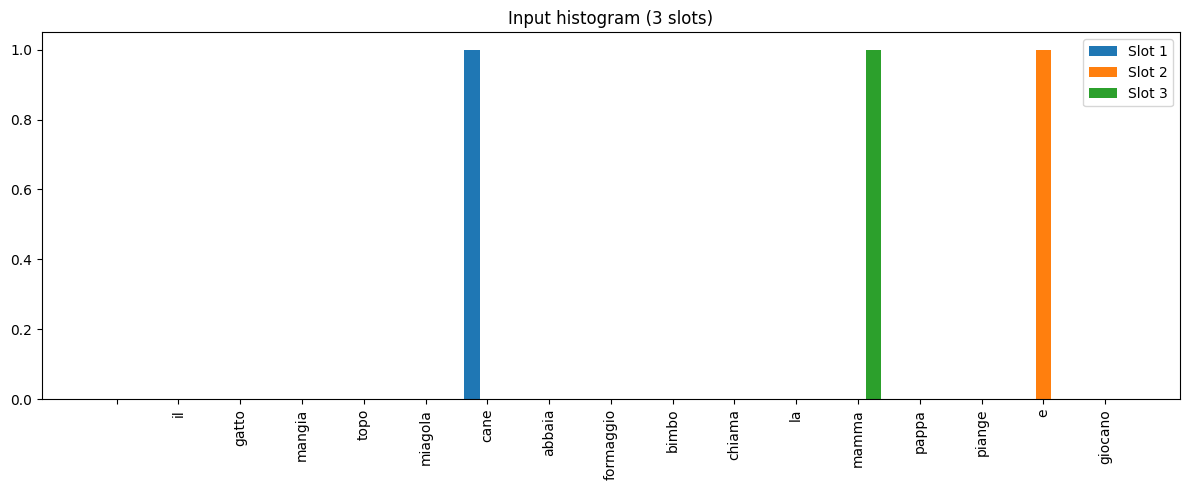

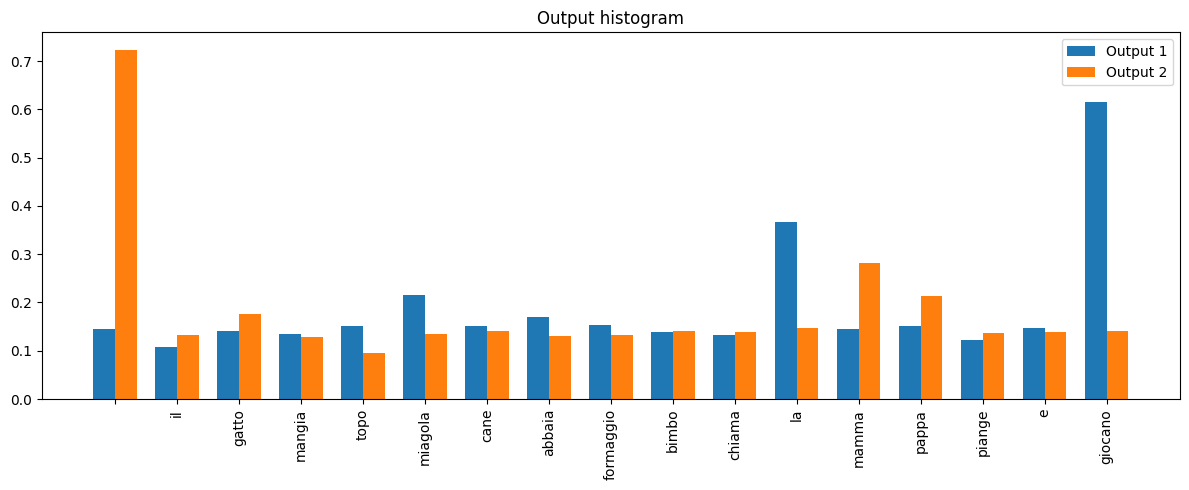

In [5]:
inOutExperiments("cane","e","mamma")

# 6
#### la rete

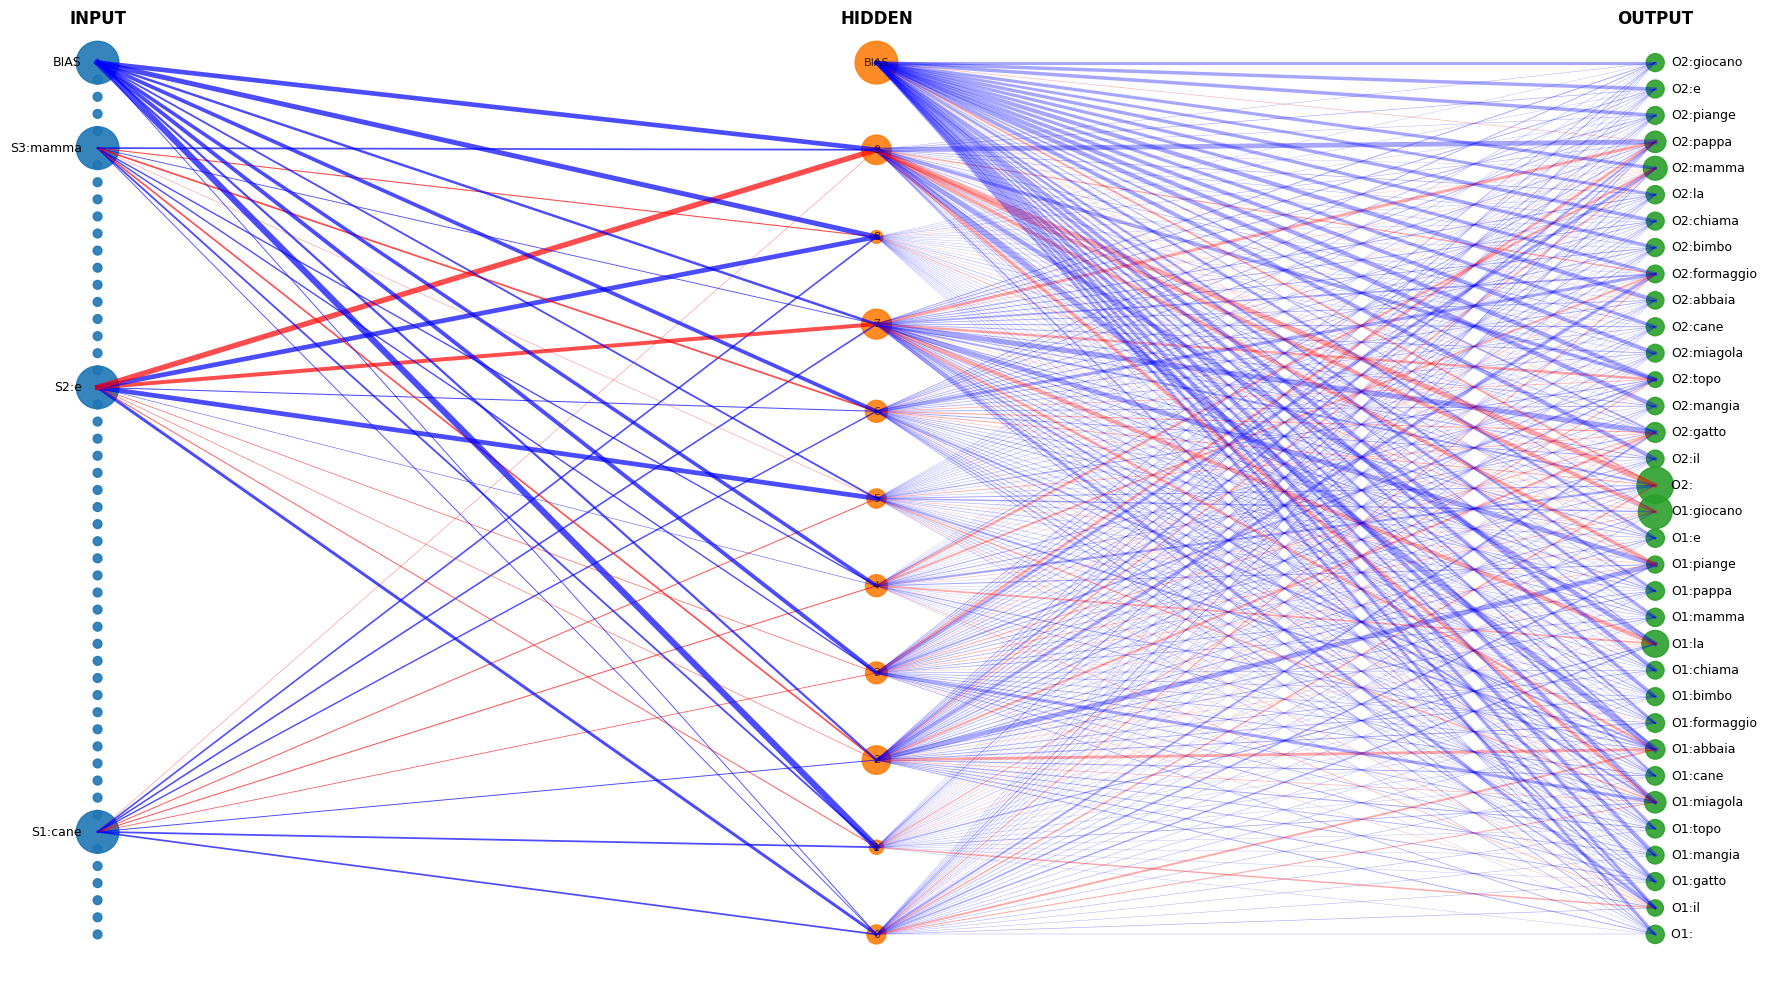

In [6]:
# fatto con ChatGPT5.2
# --- Visualizzazione 3 layer (input -> hidden -> output) con pesi colorati ---
# Requisiti:
# - weights_input_hidden, weights_hidden_output (già definiti)
# - dictionary / reverseDictionary / words (già definiti)
# - (opzionale) definisci qui una tripletta di parole e genera inExp

import numpy as np
import matplotlib.pyplot as plt

def build_inExp(i0, i1, i2):
    """Costruisce il vettore input (51,) per 3 slot da 17 parole."""
    inExp = np.zeros(17*3, dtype=float)
    inExp[dictionary[i0] + 17*0] = 1.0
    inExp[dictionary[i1] + 17*1] = 1.0
    inExp[dictionary[i2] + 17*2] = 1.0
    return inExp

def forward_activations(inExp):
    """Restituisce (input, hidden, output) attivazioni (senza nodi bias).
    Nota: i bias sono comunque usati nel forward (append di 1.0), ma NON vengono ritornati qui.
    """
    inExp = np.asarray(inExp, dtype=float).reshape(-1)
    # hidden
    inp_with_bias = np.append(inExp, 1.0)
    hidden_in = weights_input_hidden @ inp_with_bias
    hidden_out = sigmoid(hidden_in)
    # output
    hidden_with_bias = np.append(hidden_out, 1.0)
    out_in = weights_hidden_output @ hidden_with_bias
    out_out = sigmoid(out_in)
    return inExp, hidden_out, out_out

def plot_3layer_network(inExp, top_k_out=None, min_edge_strength=0.0, show_all_outputs=True):
    """Disegna rete 3-layer (input -> hidden -> output) includendo anche i nodi di bias.

    - node size ∝ attivazione
    - edge width ∝ |attivazione_sorgente * peso|
    - edge color: rosso se peso>0, blu se peso<0

    Parametri:
    - top_k_out: se non None, mostra solo i K nodi di output più attivi (per ridurre clutter).
                 Se show_all_outputs=True (default) viene ignorato e si mostrano tutti gli output.
    - min_edge_strength: soglia su |att_sorgente * peso| per disegnare un edge
    - show_all_outputs: se True mostra tutti gli output (utile quando vuoi vedere tutti e 16).
    """
    inp_act, hid_act, out_act = forward_activations(inExp)

    # --- aggiungi bias come nodi espliciti (attivazione=1.0) ---
    inp_act_b = np.append(inp_act, 1.0)      # input bias
    hid_act_b = np.append(hid_act, 1.0)      # hidden bias

    # --- selezione output ---
    out_idx = np.arange(out_act.size)
    if (not show_all_outputs) and (top_k_out is not None) and (top_k_out < out_act.size):
        out_idx = np.argsort(out_act)[::-1][:top_k_out]
        out_idx = np.sort(out_idx)

    # --- posizioni nodi (x per layer, y per indice) ---
    n_in, n_h, n_out = inp_act_b.size, hid_act_b.size, out_idx.size

    y_in  = np.linspace(0, 1, n_in)
    y_h   = np.linspace(0, 1, n_h)
    y_out = np.linspace(0, 1, n_out)

    x_in, x_h, x_out = 0.0, 1.0, 2.0

    # --- node sizes ---
    node_base, node_scale = 40, 900
    s_in  = node_base + node_scale * inp_act_b
    s_h   = node_base + node_scale * hid_act_b
    s_out = node_base + node_scale * out_act[out_idx]

    # --- labels (input/output = parole del dizionario) ---
    in_labels = []
    for slot in range(3):
        for w in words:
            in_labels.append(f"S{slot+1}:{w}")
    in_labels.append("BIAS")  # input bias

    out_labels_full = []
    # se la dimensione output è esattamente 2*len(words), manteniamo il mapping O1/O2
    if out_act.size == 2 * len(words):
        for slot in range(2):
            for w in words:
                out_labels_full.append(f"O{slot+1}:{w}")
    else:
        # fallback: etichette generiche se la rete non è 2-slot
        out_labels_full = [f"O{i}" for i in range(out_act.size)]

    out_labels = [out_labels_full[i] for i in out_idx]

    # --- edges: input->hidden (INCLUDE bias) ---
    # weights_input_hidden: (H, n_in) dove n_in = 51 + 1(bias)
    Wih_full = weights_input_hidden  # (H, 52)
    edges_ih, strength_ih, color_ih = [], [], []

    for i_in, a_in in enumerate(inp_act_b):
        if a_in == 0:
            continue
        wcol = Wih_full[:, i_in]  # (H,)
        for j_h in range(hid_act.size):
            s = abs(a_in * wcol[j_h])
            if s <= min_edge_strength:
                continue
            edges_ih.append(((x_in, y_in[i_in]), (x_h, y_h[j_h])))
            strength_ih.append(s)
            color_ih.append('red' if wcol[j_h] > 0 else 'blue')

    # --- edges: hidden->output (INCLUDE bias) ---
    # weights_hidden_output: (n_out_total, H+1) con ultima colonna=bias hidden
    Who_full = weights_hidden_output  # (n_out_total, H+1)
    edges_ho, strength_ho, color_ho = [], [], []

    for j_h, a_h in enumerate(hid_act_b):
        if a_h == 0:
            continue
        wcol = Who_full[:, j_h]  # (n_out_total,)
        for k_pos, k_out in enumerate(out_idx):
            w = wcol[k_out]
            s = abs(a_h * w)
            if s <= min_edge_strength:
                continue
            edges_ho.append(((x_h, y_h[j_h]), (x_out, y_out[k_pos])))
            strength_ho.append(s)
            color_ho.append('red' if w > 0 else 'blue')

    # --- normalizza spessori edge per plotting ---
    all_strength = np.array(strength_ih + strength_ho, dtype=float)
    if all_strength.size == 0:
        print("Nessun edge sopra soglia.")
        return
    s_max = all_strength.max()
    lw_min, lw_max = 0.2, 4.5

    def lw(s):
        return lw_min + (lw_max - lw_min) * (s / s_max)

    # --- plot ---
    plt.figure(figsize=(18, 10))
    ax = plt.gca()
    ax.set_axis_off()

    for (p0, p1), s, c in zip(edges_ih, strength_ih, color_ih):
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], linewidth=lw(s), alpha=0.7, color=c)

    for (p0, p1), s, c in zip(edges_ho, strength_ho, color_ho):
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], linewidth=lw(s), alpha=0.35, color=c)

    # nodes
    ax.scatter([x_in]*n_in,   y_in,  s=s_in,  alpha=0.9)
    ax.scatter([x_h]*n_h,     y_h,   s=s_h,   alpha=0.9)
    ax.scatter([x_out]*n_out, y_out, s=s_out, alpha=0.9)

    # etichette: input attivi + bias; output tutti (o top_k)
    for i_in, a_in in enumerate(inp_act_b):
        if a_in > 0:
            ax.text(x_in - 0.02, y_in[i_in], in_labels[i_in], va='center', ha='right', fontsize=9)

    for k, lab in enumerate(out_labels):
        ax.text(x_out + 0.02, y_out[k], lab, va='center', ha='left', fontsize=9)

    # hidden labels: numeriche, e bias esplicito
    for j_h in range(n_h):
        if j_h == n_h - 1:
            ax.text(x_h, y_h[j_h], "BIAS", va='center', ha='center', fontsize=8, alpha=0.8)
        else:
            ax.text(x_h, y_h[j_h], str(j_h), va='center', ha='center', fontsize=8, alpha=0.7)

    # layer titles
    ax.text(x_in,  1.04, 'INPUT',  ha='center', va='bottom', fontsize=12, weight='bold')
    ax.text(x_h,   1.04, 'HIDDEN', ha='center', va='bottom', fontsize=12, weight='bold')
    ax.text(x_out, 1.04, 'OUTPUT', ha='center', va='bottom', fontsize=12, weight='bold')

    plt.tight_layout()
    plt.show()

# usa la stessa tripletta dell'ultima cella ---
#inExp = build_inExp("il", "bimbo", "mangia")
inExp = build_inExp(inputPhrase[0], inputPhrase[1], inputPhrase[2])

# Mostra tutti gli output (es. tutti e 16) e include i nodi di bias
plot_3layer_network(inExp, top_k_out=None, min_edge_strength=0.0, show_all_outputs=True)
